In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("nih-chest-xrays/data")

# print("Path to dataset files:", path)

# Imports

In [3]:
# tf.keras.backend.clear_session()

In [4]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()
print("TensorFlow:", tf.__version__)


2026-05-10 21:50:04.443703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778449804.637747      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778449804.693536      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778449805.155330      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778449805.155369      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778449805.155372      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


# Load metadata and connect images

In [5]:
BASE_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = os.path.join(BASE_PATH, "Data_Entry_2017.csv")

image_paths = {}
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith(".png"):
            image_paths[file] = os.path.join(root, file)

print("Total images found:", len(image_paths))

df = pd.read_csv(CSV_PATH)
print("Metadata shape:", df.shape)
df.head()


Total images found: 112120
Metadata shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [6]:
df = df.copy()

if "View Position" in df.columns:
    df = df[df["View Position"].isin(["PA", "AP"])].copy()

df = df[
    (df["Finding Labels"] == "No Finding") |
    (df["Finding Labels"].str.contains("Pneumonia", na=False))
].copy()

df["label"] = df["Finding Labels"].apply(lambda x: 1 if "Pneumonia" in x else 0)
df["path"] = df["Image Index"].map(image_paths)

keep_cols = ["Image Index", "Finding Labels", "label", "path"]
if "Patient ID" in df.columns:
    keep_cols.append("Patient ID")
if "View Position" in df.columns:
    keep_cols.append("View Position")

df = df[keep_cols].dropna(subset=["path"]).drop_duplicates().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()


Filtered dataset shape: (61792, 6)
label
0    60361
1     1431
Name: count, dtype: int64


,Image Index,Finding Labels,label,path,Patient ID,View Position
0,00000002_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,2,PA
1,00000005_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA
2,00000005_001.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
3,00000005_002.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
4,00000005_003.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA


In [7]:
df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                  60361
Pneumonia                                                     322
Infiltration|Pneumonia                                        199
Edema|Infiltration|Pneumonia                                  137
Atelectasis|Pneumonia                                         108
                                                            ...  
Mass|Nodule|Pneumonia|Pneumothorax                              1
Atelectasis|Effusion|Infiltration|Pneumonia|Pneumothorax        1
Cardiomegaly|Consolidation|Effusion|Pneumonia                   1
Consolidation|Nodule|Pneumonia                                  1
Consolidation|Pneumonia|Mass                                    1
Name: count, Length: 143, dtype: int64

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nUnique patients:", df["Patient ID"].nunique() if "Patient ID" in df.columns else "Patient ID not found")
print("Unique images:", df["Image Index"].nunique())
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))


Missing values per column:
Image Index       0
Finding Labels    0
label             0
path              0
Patient ID        0
View Position     0
dtype: int64

Unique patients: 25052
Unique images: 61792

Class distribution:
label
0    0.976842
1    0.023158
Name: ratio, dtype: float64


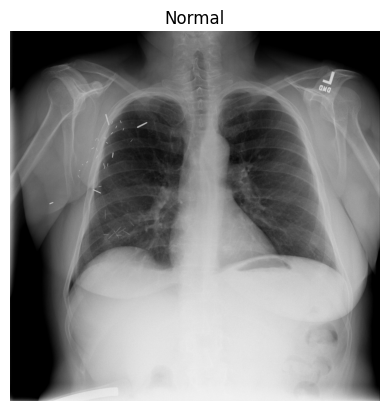

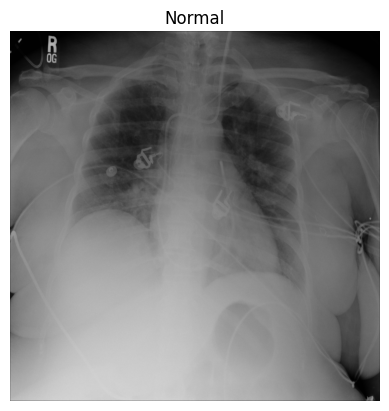

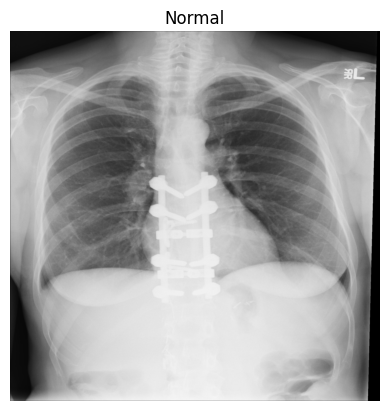

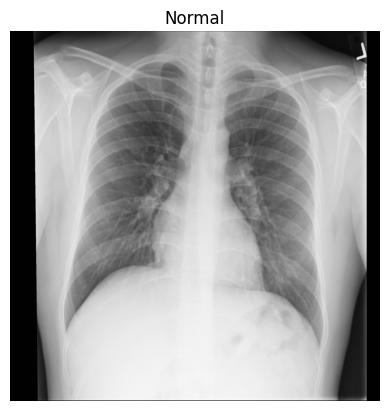

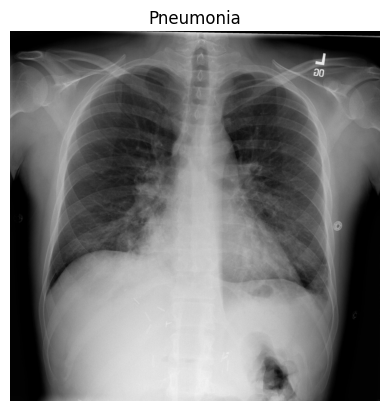

In [9]:
import cv2
import matplotlib.pyplot as plt

sample = df.sample(5)

for _, row in sample.iterrows():
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")
    plt.show()

# Data preprocessing

In [10]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())

if "Patient ID" in df.columns:
    patient_level = df.groupby("Patient ID")["label"].max().value_counts()
    print("\nPatient-level label distribution:")
    print(patient_level)

print("\nImage-level label distribution:")
print(df["label"].value_counts())


Duplicates before: 0
Duplicates after: 0

Patient-level label distribution:
label
0    24044
1     1008
Name: count, dtype: int64

Image-level label distribution:
label
0    60361
1     1431
Name: count, dtype: int64


# Class imbalance strategy

label
0    60361
1     1431
Name: count, dtype: int64
(61792, 6)


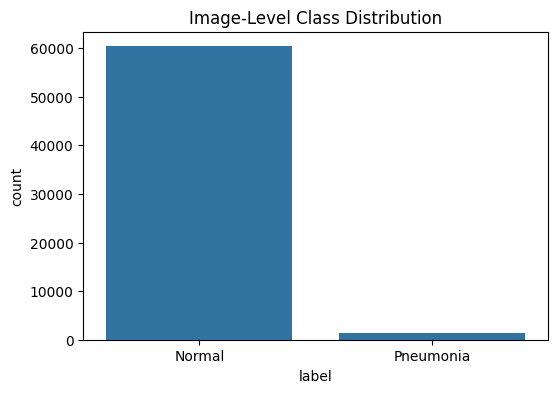

In [11]:
df_model = df.copy().reset_index(drop=True)

print(df_model["label"].value_counts())
print(df_model.shape)

plt.figure(figsize=(6, 4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Image-Level Class Distribution")
plt.show()


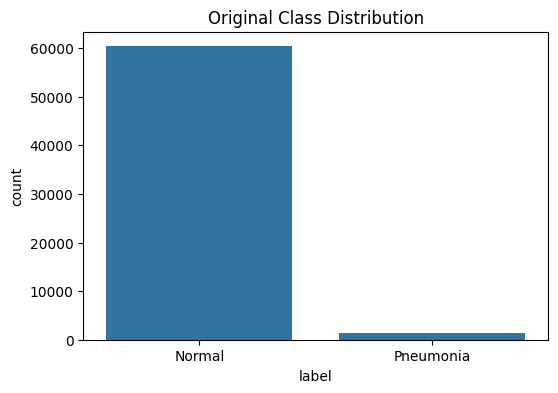

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Original Class Distribution")
plt.show()


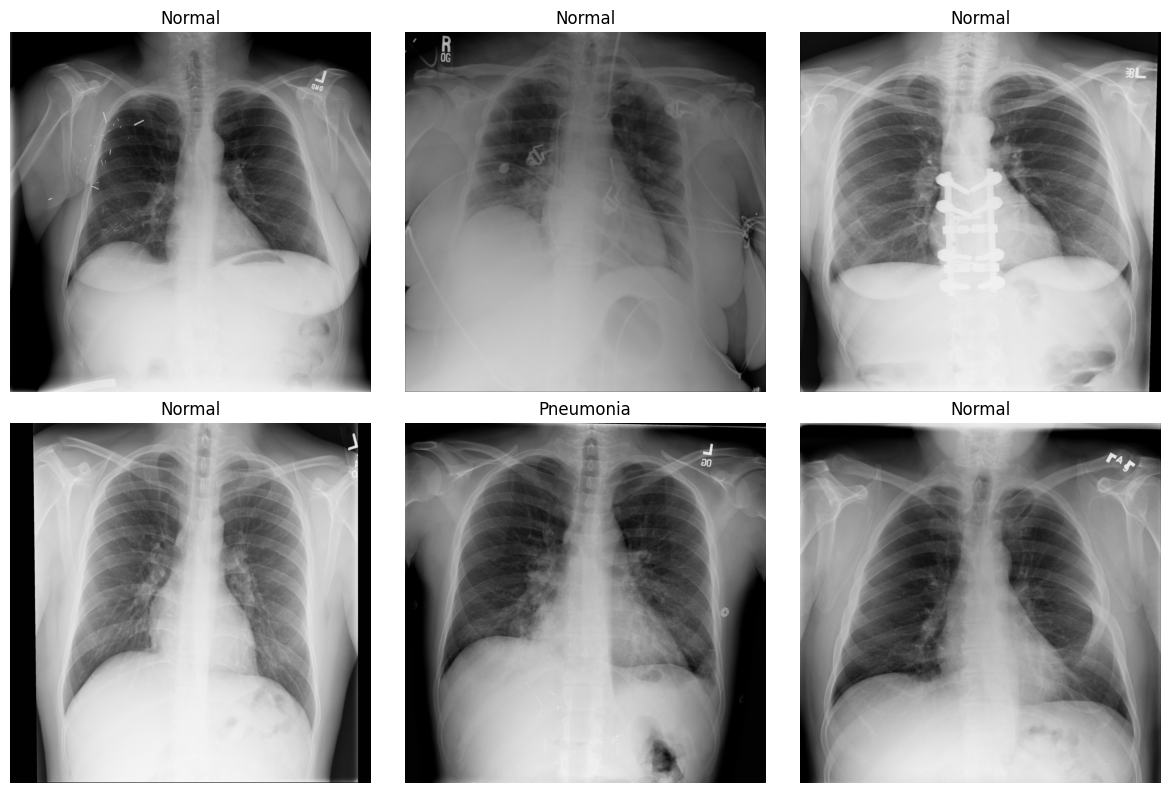

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
samples = df_model.sample(6, random_state=42).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img = cv2.imread(samples.loc[i, "path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Pneumonia" if samples.loc[i, "label"] == 1 else "Normal")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [14]:
sizes = []

for p in df_model["path"].sample(min(200, len(df_model)), random_state=42):
    img = cv2.imread(p)
    if img is not None:
        sizes.append(img.shape[:2])

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])
sizes_df.describe()


,Height,Width
count,200.0,200.0
mean,1024.0,1024.0
std,0.0,0.0
min,1024.0,1024.0
25%,1024.0,1024.0
50%,1024.0,1024.0
75%,1024.0,1024.0
max,1024.0,1024.0


In [15]:
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)

class_weights = {0: 1.0, 1: 2.0}

In [16]:
assert "Patient ID" in df_model.columns, "Patient ID column is required for patient-level split."

patient_labels = df_model.groupby("Patient ID")["label"].max().reset_index()

train_pat, temp_pat = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["label"],
    random_state=SEED
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.50,
    stratify=temp_pat["label"],
    random_state=SEED
)

train_df = df_model[df_model["Patient ID"].isin(train_pat["Patient ID"])].copy()
val_df   = df_model[df_model["Patient ID"].isin(val_pat["Patient ID"])].copy()
test_df  = df_model[df_model["Patient ID"].isin(test_pat["Patient ID"])].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())
print("\nTest label counts:")
print(test_df["label"].value_counts())

assert set(train_df["Patient ID"]).isdisjoint(set(val_df["Patient ID"]))
assert set(train_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
assert set(val_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
print("\nNo patient leakage detected.")


Train: (43018, 6)
Validation: (9271, 6)
Test: (9503, 6)

Train label counts:
label
0    42043
1      975
Name: count, dtype: int64

Validation label counts:
label
0    9070
1     201
Name: count, dtype: int64

Test label counts:
label
0    9248
1     255
Name: count, dtype: int64

No patient leakage detected.


In [17]:
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print(class_weights)


{0: 0.5115952715077421, 1: 22.06051282051282}


Original TRAIN distribution:
Counter({0: 42043, 1: 975})


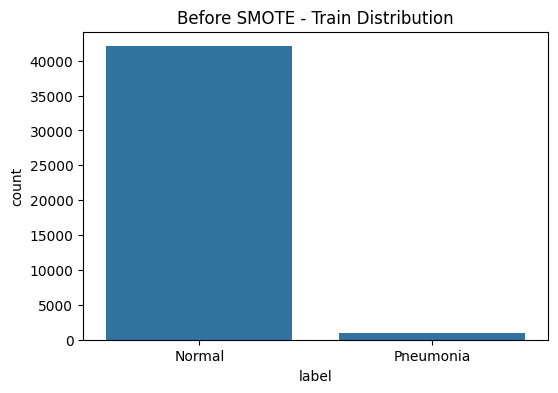


After SMOTE:
Counter({0: 42043, 1: 21021})


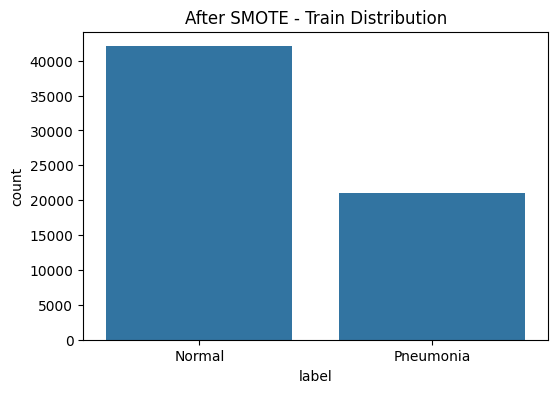


Final image-train distribution:
label
0    42043
1    21021
Name: count, dtype: int64


In [18]:
# =========================
# CLASS IMBALANCE REVIEW
# =========================
from collections import Counter
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

print("Original TRAIN distribution:")
print(Counter(train_df["label"]))

plt.figure(figsize=(6,4))
sns.countplot(x=train_df["label"])
plt.xticks([0,1], ["Normal", "Pneumonia"])
plt.title("Before SMOTE - Train Distribution")
plt.show()


# ==========================================================
# FEATURE PREP FOR SMOTE
# ==========================================================
# Since SMOTE cannot use image paths directly,
# we use structured metadata for balancing support
# (Age + Gender + View Position)
# ==========================================================

smote_train = train_df.copy()

# Gender
if "Patient Gender" in df.columns:
    gender_map = df[["Image Index", "Patient Gender"]].drop_duplicates()
    gender_map["Patient Gender"] = gender_map["Patient Gender"].map({"M":0, "F":1})
    smote_train = smote_train.merge(
        gender_map,
        on="Image Index",
        how="left"
    )
else:
    smote_train["Patient Gender"] = 0

# Age
if "Patient Age" in df.columns:
    age_map = df[["Image Index", "Patient Age"]].drop_duplicates()
    smote_train = smote_train.merge(
        age_map,
        on="Image Index",
        how="left"
    )
else:
    smote_train["Patient Age"] = 50

# View
smote_train["View Position"] = smote_train["View Position"].map({"PA":0, "AP":1})

# Fill
smote_train["Patient Age"] = smote_train["Patient Age"].fillna(smote_train["Patient Age"].median())
smote_train["Patient Gender"] = smote_train["Patient Gender"].fillna(0)

X_train_smote = smote_train[["Patient Age", "Patient Gender", "View Position"]]
y_train_smote = smote_train["label"]


# =========================
# APPLY SMOTE
# =========================
smote = SMOTE(
    sampling_strategy=0.5,   # minority becomes 50% of majority
    random_state=SEED,
    k_neighbors=3
)

X_resampled, y_resampled = smote.fit_resample(X_train_smote, y_train_smote)

print("\nAfter SMOTE:")
print(Counter(y_resampled))


# =========================
# VISUALIZE
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.xticks([0,1], ["Normal", "Pneumonia"])
plt.title("After SMOTE - Train Distribution")
plt.show()


# =========================
# BUILD BALANCED TRAIN DF
# =========================
normal_df = train_df[train_df["label"] == 0].copy()
pneumonia_df = train_df[train_df["label"] == 1].copy()

target_pneumonia = Counter(y_resampled)[1]

pneumonia_upsampled = pneumonia_df.sample(
    n=target_pneumonia,
    replace=True,
    random_state=SEED
)

train_df_balanced = pd.concat(
    [normal_df, pneumonia_upsampled],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nFinal image-train distribution:")
print(train_df_balanced["label"].value_counts())

In [19]:
IMG_SIZE = 299   
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
    tf.keras.layers.RandomZoom(0.05, 0.05),
], name="train_augmentation")


def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label


def prepare_train(path, label):
    image, label = decode_image(path, label)
    image = train_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label


def prepare_eval(path, label):
    image, label = decode_image(path, label)
    image = preprocess_input(image)
    return image, label


def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["path"].values,
        dataframe["label"].values.astype("float32")
    ))

    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(prepare_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(prepare_eval, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

I0000 00:00:1778449976.330227      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778449976.336350      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [20]:
train_gen = make_dataset(train_df, training=True)
val_gen = make_dataset(val_df, training=False)
test_gen = make_dataset(test_df, training=False)

for images, labels in train_gen.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Batch label distribution:", np.unique(labels.numpy(), return_counts=True))


Batch image shape: (16, 299, 299, 3)
Batch label shape: (16,)
Batch label distribution: (array([0., 1.], dtype=float32), array([15,  1]))


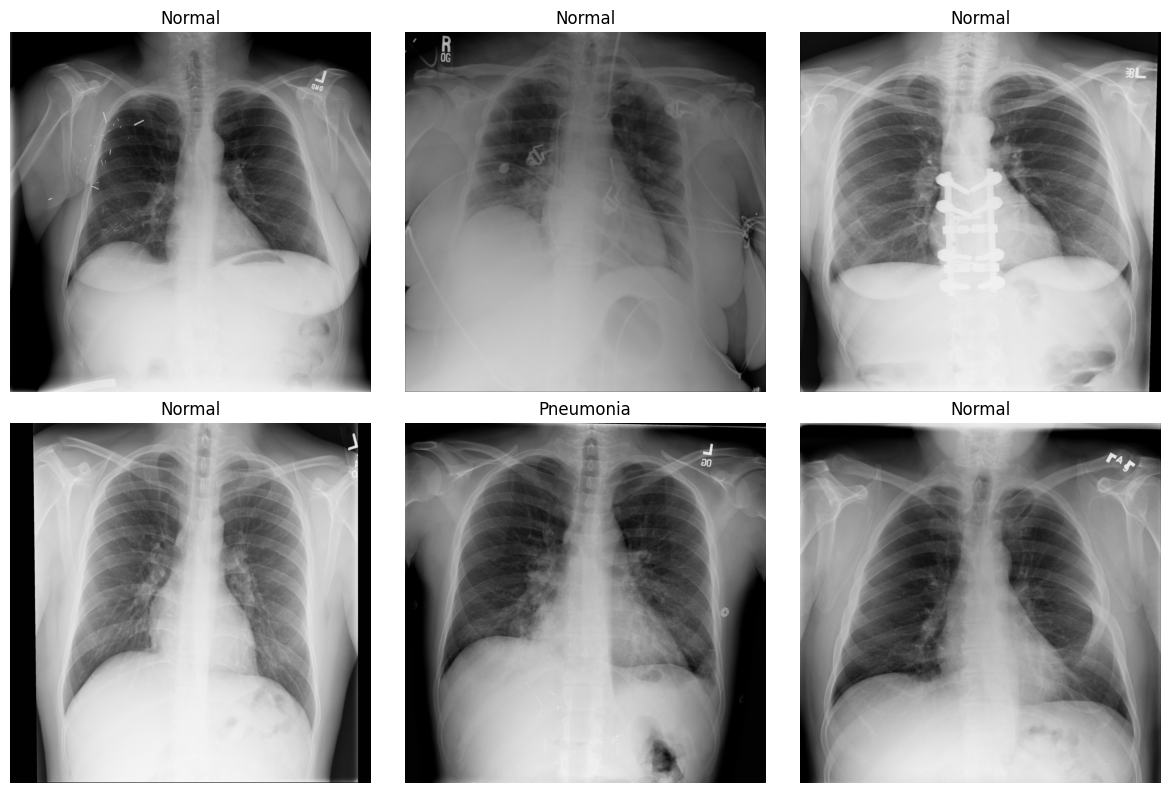

In [21]:
import matplotlib.pyplot as plt
import cv2

samples = df_model.sample(6, random_state=42)

plt.figure(figsize=(12, 8))
for i, (_, row) in enumerate(samples.iterrows()):
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")

plt.tight_layout()
plt.show()

# EfficientNet-B0 with staged fine-tuning

In [22]:
# loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.03)

# metrics = [
#     tf.keras.metrics.AUC(name="auc", curve="ROC"),
#     tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
#     tf.keras.metrics.Precision(name="precision"),
#     tf.keras.metrics.Recall(name="recall")
# ]


In [23]:
# base_model = EfficientNetB0(
#     weights="imagenet",
#     include_top=False,
#     input_shape=(IMG_SIZE, IMG_SIZE, 3)
# )

# base_model.trainable = False

# inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# x = base_model(inputs, training=False)
# x = GlobalAveragePooling2D()(x)
# x = Dropout(0.35)(x)
# output = Dense(
#     1,
#     activation="sigmoid",
#     kernel_regularizer=tf.keras.regularizers.l2(1e-4)
# )(x)

# model = Model(inputs=inputs, outputs=output)

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss=loss_fn,
#     metrics=metrics
# )

# model.summary()


In [24]:
# callbacks = [
#     EarlyStopping(
#         monitor="val_auc",
#         mode="max",
#         patience=4,
#         restore_best_weights=True,
#         verbose=1
#     ),
#     ReduceLROnPlateau(
#         monitor="val_auc",
#         mode="max",
#         factor=0.3,
#         patience=2,
#         min_lr=1e-6,
#         verbose=1
#     ),
#     ModelCheckpoint(
#         "best_stage1.keras",
#         monitor="val_auc",
#         mode="max",
#         save_best_only=True,
#         verbose=1
#     )
# ]


In [25]:
# history_head = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=15,
#     class_weight=class_weights,
#     callbacks=callbacks,
#     verbose=1
# )


In [26]:
# base_model.trainable = True

# for layer in base_model.layers[:-30]:
#     layer.trainable = False

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss=loss_fn,
#     metrics=metrics
# )

# callbacks_ft = [
#     EarlyStopping(
#         monitor="val_auc",
#         mode="max",
#         patience=4,
#         restore_best_weights=True,
#         verbose=1
#     ),
#     ReduceLROnPlateau(
#         monitor="val_auc",
#         mode="max",
#         factor=0.3,
#         patience=2,
#         min_lr=1e-7,
#         verbose=1
#     ),
#     ModelCheckpoint(
#         "best_finetuned.keras",
#         monitor="val_auc",
#         mode="max",
#         save_best_only=True,
#         verbose=1
#     )
# ]

# history_ft_stage1 = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=12,
#     class_weight=class_weights,
#     callbacks=callbacks_ft,
#     verbose=1
# )


In [27]:
# val_true = val_df["label"].values.astype(int)
# val_prob = model.predict(val_gen, verbose=1).ravel()

# precisions, recalls, thresholds = precision_recall_curve(val_true, val_prob)
# f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)

# best_idx = np.argmax(f1_scores)
# best_threshold = thresholds[best_idx]
# best_val_f1 = f1_scores[best_idx]

# print("Best threshold:", best_threshold)
# print("Best validation F1:", best_val_f1)


In [28]:
# for t in [0.10, 0.20, float(best_threshold), 0.35, 0.50]:
#     y_pred = (val_prob >= t).astype(int)
#     print(f"\nThreshold = {t:.4f}")
#     print(confusion_matrix(val_true, y_pred))
#     print(classification_report(val_true, y_pred, digits=4, zero_division=0))


In [29]:
# print("Validation ROC-AUC:", roc_auc_score(val_true, val_prob))
# print("Validation PR-AUC:", average_precision_score(val_true, val_prob))
# print("Mean predicted probability:", val_prob.mean())
# print("Min predicted probability:", val_prob.min())
# print("Max predicted probability:", val_prob.max())
# print("Predicted positives at best threshold:", int((val_prob >= best_threshold).sum()))


In [30]:
# test_loss, test_auc, test_pr_auc, test_precision, test_recall = model.evaluate(
#     test_gen,
#     verbose=1
# )

# print(f"loss: {test_loss:.4f}")
# print(f"auc: {test_auc:.4f}")
# print(f"pr_auc: {test_pr_auc:.4f}")
# print(f"precision@0.5: {test_precision:.4f}")
# print(f"recall@0.5: {test_recall:.4f}")


In [31]:
# y_true = test_df["label"].values.astype(int)
# y_prob = model.predict(test_gen, verbose=1).ravel()
# y_pred = (y_prob >= best_threshold).astype(int)

# print("Confusion Matrix:")
# print(confusion_matrix(y_true, y_pred))

# print("\nClassification Report:")
# print(classification_report(y_true, y_pred, digits=4, zero_division=0))


In [32]:
# def plot_history(histories, metric="auc"):
#     plt.figure(figsize=(8, 5))
#     for name, hist in histories.items():
#         if metric in hist.history and f"val_{metric}" in hist.history:
#             plt.plot(hist.history[metric], label=f"{name} train")
#             plt.plot(hist.history[f"val_{metric}"], label=f"{name} val")
#     plt.title(metric.upper())
#     plt.xlabel("Epoch")
#     plt.ylabel(metric.upper())
#     plt.legend()
#     plt.show()

# histories = {
#     "fine_tune": history_ft_stage1
# }

# for metric_name in ["loss", "auc", "pr_auc", "precision", "recall"]:
#     plot_history(histories, metric_name)

In [33]:
# cm = confusion_matrix(y_true, y_pred)
# tn, fp, fn, tp = cm.ravel()

# sensitivity = tp / (tp + fn + 1e-8)
# specificity = tn / (tn + fp + 1e-8)
# precision_best = precision_score(y_true, y_pred, zero_division=0)
# recall_best = recall_score(y_true, y_pred, zero_division=0)
# f1 = f1_score(y_true, y_pred, zero_division=0)
# roc_auc = roc_auc_score(y_true, y_prob)
# pr_auc = average_precision_score(y_true, y_prob)

# metrics_df = pd.DataFrame({
#     "Metric": ["Precision", "Recall / Sensitivity", "Specificity", "F1-score", "ROC-AUC", "PR-AUC", "Best Threshold"],
#     "Value": [precision_best, recall_best, specificity, f1, roc_auc, pr_auc, best_threshold]
# })
# metrics_df


In [34]:
# import numpy as np
# import matplotlib.pyplot as plt
# from PIL import Image
# from lime import lime_image
# from skimage.segmentation import mark_boundaries

# explainer = lime_image.LimeImageExplainer()



# def predict_fn(images):
#     images = np.array(images)
#     return np.concatenate([1 - model.predict(images), model.predict(images)], axis=1)

In [35]:
# sample_path = val_df.sample(1)['path'].values[0]

# img = Image.open(sample_path).convert("RGB").resize((224, 224))
# img_array = np.array(img) / 255.0

# explanation = explainer.explain_instance(
#     img_array.astype('double'),
#     predict_fn,
#     top_labels=1,
#     hide_color=0,
#     num_samples=1000
# )

In [36]:
# temp, mask = explanation.get_image_and_mask(
#     explanation.top_labels[0],
#     positive_only=True,
#     num_features=10,
#     hide_rest=False
# )

# plt.figure(figsize=(6,6))
# plt.imshow(mark_boundaries(temp, mask))
# plt.title("LIME Explanation")
# plt.axis("off")
# plt.show()

In [37]:
# orig_pred = model.predict(np.expand_dims(img_array, axis=0))[0][0]
# print("Original prediction:", orig_pred)


# # keep only important regions
# important_only = img_array.copy()
# important_only[mask == 0] = 0

# important_pred = model.predict(np.expand_dims(important_only, axis=0))[0][0]

# print("Prediction with important regions:", important_pred)


# # remove important regions
# removed = img_array.copy()
# removed[mask == 1] = 0

# removed_pred = model.predict(np.expand_dims(removed, axis=0))[0][0]

# print("Prediction without important regions:", removed_pred)

# decision_impact = abs(orig_pred - removed_pred)
# confidence_impact = abs(orig_pred - important_pred)

# print("Decision Impact:", decision_impact)
# print("Confidence Impact:", confidence_impact)

In [38]:
# plt.figure(figsize=(6, 5))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     xticklabels=["Normal", "Pneumonia"],
#     yticklabels=["Normal", "Pneumonia"]
# )
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix at Best Threshold")
# plt.show()

# fpr, tpr, _ = roc_curve(y_true, y_prob)
# plt.figure(figsize=(6, 5))
# plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
# plt.plot([0, 1], [0, 1], linestyle="--")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend()
# plt.show()

# prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
# plt.figure(figsize=(6, 5))
# plt.plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.4f}")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.title("Precision-Recall Curve")
# plt.legend()
# plt.show()

# print(metrics_df)


In [39]:
# last_conv_layer_name = None
# for layer in reversed(base_model.layers):
#     if isinstance(layer, tf.keras.layers.Conv2D):
#         last_conv_layer_name = layer.name
#         break

# print("Last conv layer:", last_conv_layer_name)


In [40]:
# def get_gradcam_heatmap(model, img_array, last_conv_layer_name="top_conv"):
#     base_model = None
#     top_start_idx = None

#     for i, layer in enumerate(model.layers):
#         if isinstance(layer, tf.keras.Model):
#             base_model = layer
#             top_start_idx = i + 1
#             break

#     if base_model is None:
#         raise ValueError("Backbone model not found inside model.")

#     last_conv_layer = base_model.get_layer(last_conv_layer_name)

#     conv_model = tf.keras.Model(
#         inputs=base_model.input,
#         outputs=last_conv_layer.output
#     )

#     classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
#     x = classifier_input

#     passed_last = False
#     for layer in base_model.layers:
#         if layer.name == last_conv_layer_name:
#             passed_last = True
#             continue
#         if passed_last:
#             x = layer(x)

#     for layer in model.layers[top_start_idx:]:
#         x = layer(x)

#     classifier_model = tf.keras.Model(classifier_input, x)

#     with tf.GradientTape() as tape:
#         inputs = img_array
#         conv_outputs = conv_model(inputs, training=False)
#         tape.watch(conv_outputs)
#         predictions = classifier_model(conv_outputs, training=False)
#         loss = predictions[:, 0]

#     grads = tape.gradient(loss, conv_outputs)
#     pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

#     conv_outputs = conv_outputs[0]
#     heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

#     heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
#     return heatmap.numpy()

In [41]:
# def load_image_for_model(img_path, size=(224, 224)):
#     img = tf.io.read_file(img_path)
#     img = tf.image.decode_png(img, channels=1)
#     img = tf.image.resize(img, size)
#     img = tf.image.grayscale_to_rgb(img)
#     img = tf.cast(img, tf.float32)
#     img = preprocess_input(img)
#     return tf.expand_dims(img, axis=0)

# pneumonia_df = test_df[test_df["label"] == 1]

# sample_row = pneumonia_df.sample(2, random_state=SEED).iloc[0]
# img_path = sample_row["path"]

# img_array = load_image_for_model(img_path, size=(IMG_SIZE, IMG_SIZE))
# heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name)

# img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
# img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
# img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

# heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
# heatmap_uint8 = np.uint8(255 * heatmap)
# heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
# heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# superimposed = cv2.addWeighted(img_rgb, 0.6, heatmap_color, 0.4, 0)

# plt.figure(figsize=(12, 4))

# plt.subplot(1, 3, 1)
# plt.imshow(img_rgb, cmap="gray")
# plt.title("Original Pneumonia")
# plt.axis("off")

# plt.subplot(1, 3, 2)
# plt.imshow(heatmap_color)
# plt.title("Grad-CAM")
# plt.axis("off")

# plt.subplot(1, 3, 3)
# plt.imshow(superimposed)
# plt.title("Overlay")
# plt.axis("off")

# plt.show()



# save_path = "outputs/gradcam_pneumonia.png"
# plt.savefig(save_path, dpi=300, bbox_inches="tight")
# print("Saved to:", save_path)

# plt.show()

# # ===== Prediction =====
# pred = model.predict(img_array, verbose=0)

# if pred.shape[-1] == 1:  # sigmoid
#     pred_prob = float(pred[0][0])
#     pred_label = int(pred_prob >= best_threshold)
# else:  # softmax
#     pred_prob = float(pred[0][1])
#     pred_label = int(np.argmax(pred[0]))

# print("True label:", "Pneumonia")
# print("Predicted probability:", round(pred_prob, 4))
# print("Predicted label:", "Pneumonia" if pred_label == 1 else "Normal")
# print("Threshold used:", best_threshold)

# Model 2: Xception

In [42]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf

IMG_SIZE = 299   # Xception preferred input size
BATCH_SIZE = 16

In [43]:
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

xception_model = Model(inputs, outputs)

metrics = [
    tf.keras.metrics.AUC(name="auc", curve="ROC"),
    tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]

loss_fn = tf.keras.losses.BinaryFocalCrossentropy(
    gamma=2.0,
    apply_class_balancing=True
)

xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=metrics
)

xception_model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,871,721 (79.62 MB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 20,865,576 (79.60 MB)

In [44]:
callbacks_xception_head = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "/kaggle/working/best_xception_head.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history_xception_head = xception_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks_xception_head,
    verbose=1
)

Epoch 1/5


I0000 00:00:1778449987.967852     140 service.cc:152] XLA service 0x7d718001aae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778449987.967918     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778449987.967924     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778449989.967167     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-10 21:53:17.709781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 21:53:17.925443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 21:53:20.404972: E external/local_xl

2688/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - auc: 0.5210 - loss: 0.1419 - pr_auc: 0.0235 - precision: 0.0240 - recall: 0.3157

2026-05-10 22:07:14.680862: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 22:07:14.906853: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 22:07:15.666258: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 22:07:15.858969: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 22:07:16.546793: E external/local_xla/xla/stream_

2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - auc: 0.5210 - loss: 0.1419 - pr_auc: 0.0235 - precision: 0.0240 - recall: 0.3157

2026-05-10 22:08:54.327542: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 22:08:54.547941: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 22:08:55.281388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 22:08:55.456295: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 22:08:56.074959: E external/local_xla/xla/stream_


Epoch 1: val_auc improved from -inf to 0.61779, saving model to /kaggle/working/best_xception_head.keras
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 969s 348ms/step - auc: 0.5210 - loss: 0.1419 - pr_auc: 0.0235 - precision: 0.0240 - recall: 0.3157 - val_auc: 0.6178 - val_loss: 0.0747 - val_pr_auc: 0.0339 - val_precision: 0.0399 - val_recall: 0.2239 - learning_rate: 1.0000e-04
Epoch 2/5
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - auc: 0.6069 - loss: 0.1047 - pr_auc: 0.0343 - precision: 0.0368 - recall: 0.3070
Epoch 2: val_auc improved from 0.61779 to 0.62629, saving model to /kaggle/working/best_xception_head.keras
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 833s 310ms/step - auc: 0.6069 - loss: 0.1047 - pr_auc: 0.0343 - precision: 0.0368 - recall: 0.3070 - val_auc: 0.6263 - val_loss: 0.0593 - val_pr_auc: 0.0373 - val_precision: 0.0490 - val_recall: 0.1791 - learning_rate: 1.0000e-04
Epoch 3/5
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - auc: 0.6140 - loss: 0.0953 - pr_auc: 0.0356 - precision: 0.0418 - rec

In [45]:
# Save final head-training model after training finishes
xception_model.save("/kaggle/working/xception_head_final.keras")
print("✅ Xception head-trained model saved successfully!")

✅ Xception head-trained model saved successfully!


In [46]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-1),
    loss=loss_fn,
    metrics=metrics
)

callbacks_xception_ft = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "/kaggle/working/best_xception_finetuned.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history_xception_ft = xception_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks_xception_ft,
    verbose=1
)

Epoch 1/5


2026-05-10 23:05:00.477654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 23:05:00.620355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 23:05:01.152376: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 23:05:01.290895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 23:05:01.601156: E external/local_xla/xla/stream_

2688/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - auc: 0.5464 - loss: 11.4325 - pr_auc: 0.0276 - precision: 0.0357 - recall: 0.2736

2026-05-10 23:21:09.620361: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 23:21:09.758204: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 23:21:10.176628: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 23:21:10.315036: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 23:21:10.597509: E external/local_xla/xla/stream_

2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - auc: 0.5464 - loss: 11.4324 - pr_auc: 0.0276 - precision: 0.0357 - recall: 0.2736
Epoch 1: val_auc improved from -inf to 0.50000, saving model to /kaggle/working/best_xception_finetuned.keras
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 1089s 393ms/step - auc: 0.5464 - loss: 11.4323 - pr_auc: 0.0276 - precision: 0.0357 - recall: 0.2736 - val_auc: 0.5000 - val_loss: 0.5475 - val_pr_auc: 0.0217 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.1000
Epoch 2/5
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - auc: 0.5229 - loss: 9.1791 - pr_auc: 0.0257 - precision: 0.0271 - recall: 0.2761
Epoch 2: val_auc improved from 0.50000 to 0.53073, saving model to /kaggle/working/best_xception_finetuned.keras
2689/2689 ━━━━━━━━━━━━━━━━━━━━ 1010s 375ms/step - auc: 0.5229 - loss: 9.1794 - pr_auc: 0.0257 - precision: 0.0271 - recall: 0.2761 - val_auc: 0.5307 - val_loss: 0.1049 - val_pr_auc: 0.0313 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 -

In [48]:
# Save final fine-tuned model
history_xception_ft.save("/kaggle/working/xception_finetuned_final.keras")

# Optional: save also as H5
history_xception_ft.save("/kaggle/working/xception_finetuned_final.h5")

print("✅ Xception fine-tuned model saved successfully!")

AttributeError: 'History' object has no attribute 'save'

In [49]:
from sklearn.metrics import (
    precision_recall_curve, classification_report,
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)
import numpy as np
xception_model = tf.keras.models.load_model("best_xception_finetuned.keras")

val_true = val_df["label"].values.astype(int)
val_prob = xception_model.predict(val_gen, verbose=1).ravel()

precisions, recalls, thresholds = precision_recall_curve(val_true, val_prob)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold_xception = thresholds[best_idx]

print("Best Xception threshold:", best_threshold_xception)
print("Best validation F1:", f1_scores[best_idx])

580/580 ━━━━━━━━━━━━━━━━━━━━ 84s 126ms/step
Best Xception threshold: 0.27118307
Best validation F1: 0.09824560946943696


In [50]:
y_true = test_df["label"].values.astype(int)
y_prob = xception_model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= best_threshold_xception).astype(int)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_true, y_prob))
print("PR-AUC:", average_precision_score(y_true, y_prob))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1:", f1_score(y_true, y_pred, zero_division=0))
print("Specificity:", tn / (tn + fp + 1e-8))

593/594 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

2026-05-11 00:35:44.198070: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:35:44.426656: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:35:45.207083: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:35:45.424386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:35:46.222738: E external/local_xla/xla/stream_

594/594 ━━━━━━━━━━━━━━━━━━━━ 90s 151ms/step
Confusion Matrix:
[[8783  465]
 [ 210   45]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9766    0.9497    0.9630      9248
           1     0.0882    0.1765    0.1176       255

    accuracy                         0.9290      9503
   macro avg     0.5324    0.5631    0.5403      9503
weighted avg     0.9528    0.9290    0.9403      9503

ROC-AUC: 0.7128218501933644
PR-AUC: 0.06644027962352758
Precision: 0.08823529411764706
Recall: 0.17647058823529413
F1: 0.11764705882352941
Specificity: 0.9497188581304609


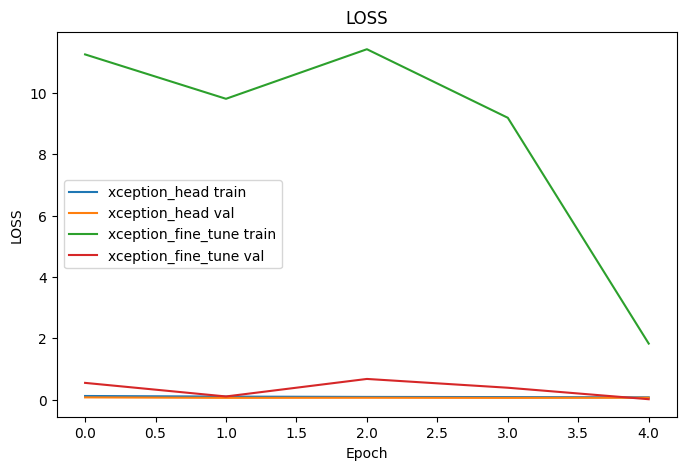

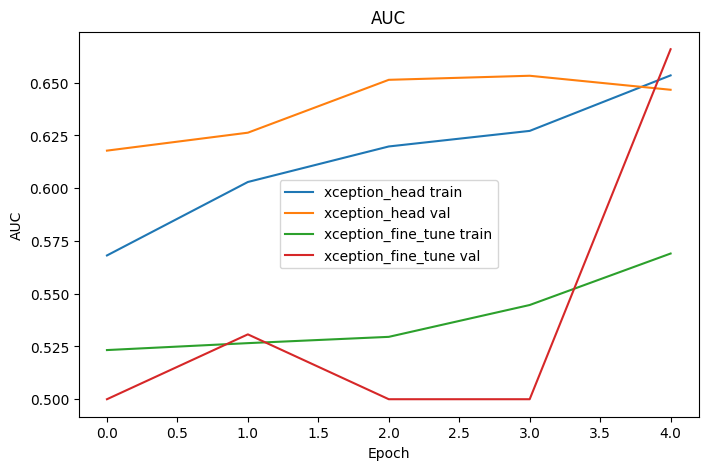

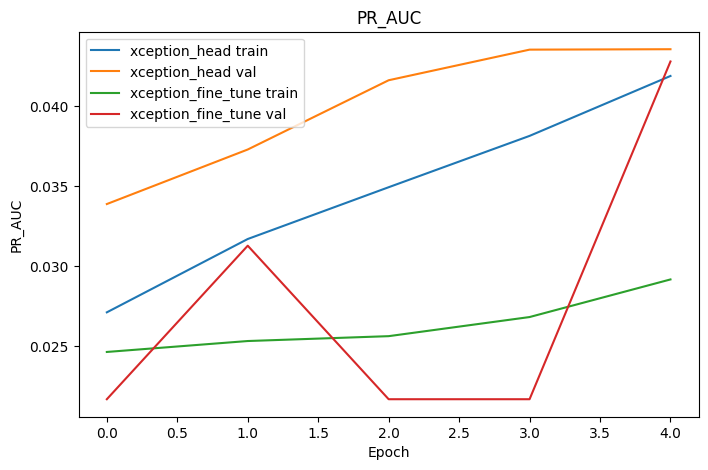

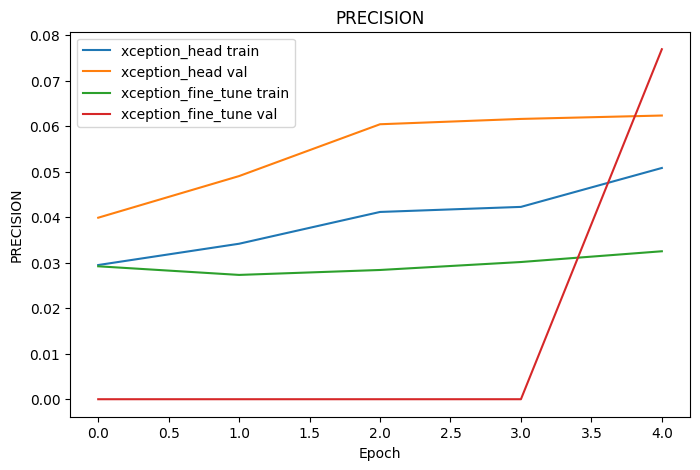

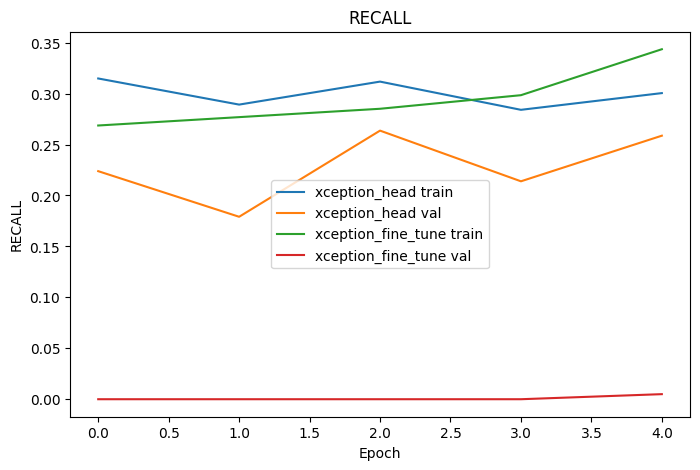

In [54]:
def plot_history(histories, metric="auc"):
    plt.figure(figsize=(8, 5))

    for name, hist in histories.items():
        history_dict = hist.history

        if metric in history_dict and f"val_{metric}" in history_dict:
            plt.plot(history_dict[metric], label=f"{name} train")
            plt.plot(history_dict[f"val_{metric}"], label=f"{name} val")

    plt.title(metric.upper())
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.show()


histories = {
    "xception_head": history_xception_head,
    "xception_fine_tune": history_xception_ft
}

for metric_name in ["loss", "auc", "pr_auc", "precision", "recall"]:
    plot_history(histories, metric_name)

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications.xception import preprocess_input

explainer = lime_image.LimeImageExplainer()

def predict_fn_xception(images):
    images = np.array(images).astype("float32")
    images = preprocess_input(images)

    probs = xception_model.predict(images, verbose=0)

    if probs.shape[-1] == 1:  # sigmoid binary model
        probs = probs.ravel()
        return np.stack([1 - probs, probs], axis=1)

    return probs

  0%|          | 0/1000 [00:00<?, ?it/s]

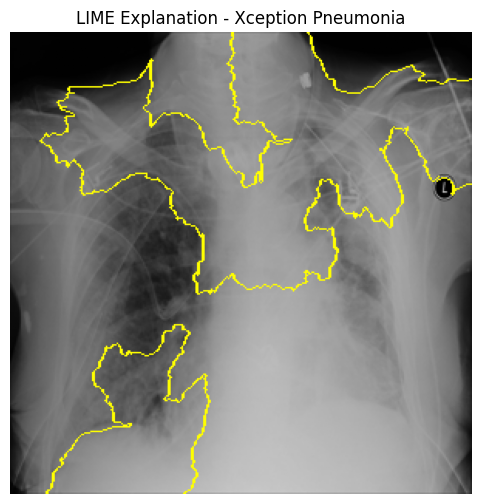

2026-05-11 00:38:05.879819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:06.023425: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:06.789172: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:06.922103: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:07.700826: E external/local_xla/xla/stream_

True label: Pneumonia
Predicted probability: 0.1906
Predicted label: Normal
Threshold used: 0.27118307


In [56]:
sample_row = test_df[test_df["label"] == 1].sample(1, random_state=SEED).iloc[0]
img_path = sample_row["path"]

img = Image.open(img_path).convert("RGB")
img = img.resize((299, 299))
img_np = np.array(img)

explanation = explainer.explain_instance(
    img_np,
    predict_fn_xception,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    label=1,                 # Pneumonia class
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation - Xception Pneumonia")
plt.axis("off")
plt.show()

pred_prob = float(xception_model.predict(
    preprocess_input(np.expand_dims(img_np.astype("float32"), axis=0)),
    verbose=0
).ravel()[0])

print("True label:", "Pneumonia" if sample_row["label"] == 1 else "Normal")
print("Predicted probability:", round(pred_prob, 4))
print("Predicted label:", "Pneumonia" if pred_prob >= best_threshold_xception else "Normal")
print("Threshold used:", best_threshold_xception)

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.xception import preprocess_input

In [58]:
def load_xception_image(path, size=(299, 299)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    img = np.array(img).astype("float32")
    return img

# background = small normal sample
background_paths = test_df[test_df["label"] == 0]["path"].sample(
    20, random_state=SEED
).values

# explain pneumonia samples
explain_paths = test_df[test_df["label"] == 1]["path"].sample(
    3, random_state=SEED
).values

background = np.array([load_xception_image(p) for p in background_paths])
to_explain = np.array([load_xception_image(p) for p in explain_paths])

background_preprocessed = preprocess_input(background.copy())
to_explain_preprocessed = preprocess_input(to_explain.copy())

In [59]:
def predict_xception(images):
    images = images.astype("float32")
    images = preprocess_input(images.copy())
    preds = xception_model.predict(images, verbose=0)
    return preds

In [60]:
masker = shap.maskers.Image("blur(32,32)", shape=(299, 299, 3))

explainer = shap.Explainer(
    predict_xception,
    masker,
    output_names=["Pneumonia"]
)

In [61]:
shap_values = explainer(
    to_explain,
    max_evals=200,
    batch_size=8
)

2026-05-11 00:38:30.971729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:31.118672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:32.524382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:32.669487: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:33.438783: E external/local_xla/xla/stream_

  0%|          | 0/198 [00:00<?, ?it/s]

2026-05-11 00:38:49.850109: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:50.030372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:52.022429: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:52.183371: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:38:53.220041: E external/local_xla/xla/stream_

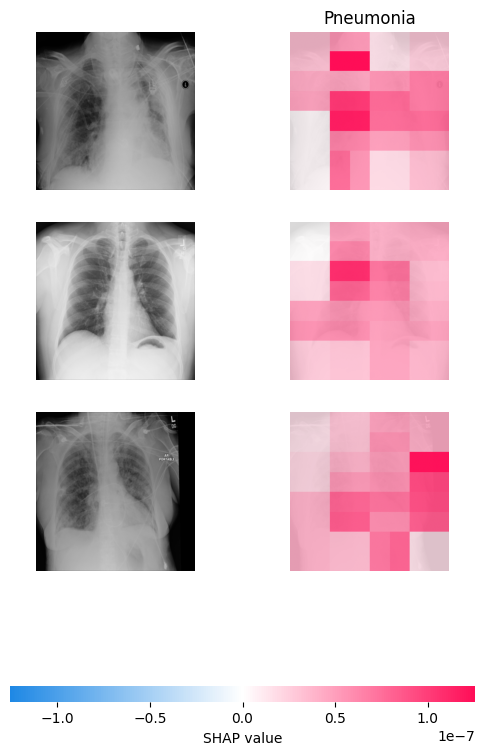

In [63]:
shap.image_plot(shap_values, to_explain / 255.0)

In [62]:
pred_probs = xception_model.predict(to_explain_preprocessed, verbose=0).ravel()

for i, prob in enumerate(pred_probs):
    pred_label = int(prob >= best_threshold_xception)
    print(f"Image {i+1}")
    print("True label: Pneumonia")
    print("Predicted probability:", round(float(prob), 4))
    print("Predicted label:", "Pneumonia" if pred_label == 1 else "Normal")
    print("-" * 40)

2026-05-11 00:39:43.029930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:39:43.183533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:39:44.607987: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:39:44.756309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 00:39:45.547633: E external/local_xla/xla/stream_

Image 1
True label: Pneumonia
Predicted probability: 0.1906
Predicted label: Normal
----------------------------------------
Image 2
True label: Pneumonia
Predicted probability: 0.1907
Predicted label: Normal
----------------------------------------
Image 3
True label: Pneumonia
Predicted probability: 0.1903
Predicted label: Normal
----------------------------------------


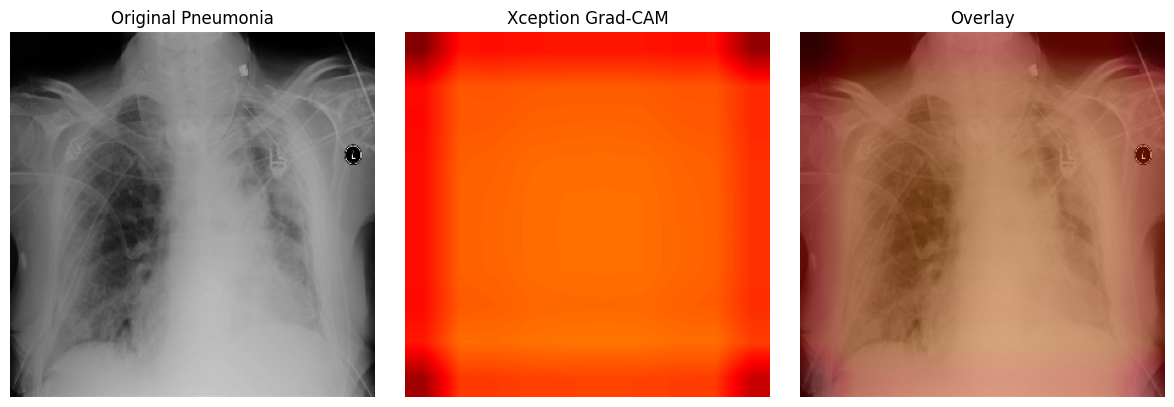

Saved to: /kaggle/working/outputs/xception_gradcam_pneumonia.png
True label:            Pneumonia
Predicted probability: 0.1907
Predicted label:       Normal
Threshold used:        0.27118307


In [70]:
# ============================================================
# Grad-CAM for Xception Model (All-in-One Cell)
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.xception import preprocess_input

# ------------------------------------------------------------
# 1. Load and preprocess a single image for Xception
# ------------------------------------------------------------
def load_image_for_xception(img_path, size=(IMG_SIZE, IMG_SIZE)):
    """
    Load and preprocess a grayscale chest X-ray image for Xception.
    
    Steps:
    1. Read image from disk
    2. Decode as grayscale (1 channel)
    3. Resize to IMG_SIZE x IMG_SIZE
    4. Convert grayscale -> RGB (Xception requires 3 channels)
    5. Convert to float32
    6. Apply Xception preprocess_input()
    7. Add batch dimension
    """
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, size)
    img = tf.image.grayscale_to_rgb(img)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return tf.expand_dims(img, axis=0)


# ------------------------------------------------------------
# 2. Compute Grad-CAM Heatmap
# ------------------------------------------------------------
def get_gradcam_heatmap_xception(
    model,
    img_array,
    last_conv_layer_name='block14_sepconv2_act',
    class_index=None
):
    """
    Compute Grad-CAM heatmap for an Xception-based transfer learning model.

    Parameters
    ----------
    model : tf.keras.Model
        Full transfer learning model (Xception backbone + custom head)
    img_array : Tensor
        Preprocessed image with shape (1, IMG_SIZE, IMG_SIZE, 3)
    last_conv_layer_name : str
        Final convolutional layer in Xception
    class_index : int or None
        Class to explain. None = predicted class

    Returns
    -------
    heatmap : np.ndarray
        Normalized 2D heatmap in range [0, 1]
    """

    # --------------------------------------------------------
    # Find the Xception backbone inside the full model
    # --------------------------------------------------------
    backbone = None
    top_start_idx = None

    for i, layer in enumerate(model.layers):
        if isinstance(layer, tf.keras.Model):
            backbone = layer
            top_start_idx = i + 1
            break

    if backbone is None:
        raise ValueError("Xception backbone not found inside the model.")

    # --------------------------------------------------------
    # Get the last convolutional layer
    # --------------------------------------------------------
    try:
        last_conv_layer = backbone.get_layer(last_conv_layer_name)
    except ValueError:
        print("\nAvailable final layers in backbone:\n")
        for layer in backbone.layers[-30:]:
            print(layer.name)
        raise ValueError(
            f"Layer '{last_conv_layer_name}' not found.\n"
            "Recommended layer: 'block14_sepconv2_act'"
        )

    # --------------------------------------------------------
    # Model that outputs:
    # 1. Feature maps from last conv layer
    # 2. Backbone final output
    # --------------------------------------------------------
    grad_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    # --------------------------------------------------------
    # Forward pass and gradient calculation
    # --------------------------------------------------------
    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = grad_model(img_array, training=False)

        # Pass through custom classification head
        x = base_outputs
        for layer in model.layers[top_start_idx:]:
            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)

        preds = x

        # Binary classification
        if preds.shape[-1] == 1:
            loss = preds[:, 0]
        else:
            if class_index is None:
                class_index = tf.argmax(preds[0])
            loss = preds[:, class_index]

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        raise ValueError(
            "Gradients are None. "
            "Check last_conv_layer_name='block14_sepconv2_act'"
        )

    # Global average pooling over height and width
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weighted sum of feature maps
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize to [0, 1]
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


# ------------------------------------------------------------
# 3. Visualize Grad-CAM
# ------------------------------------------------------------
def show_xception_gradcam(
    model,
    test_df,
    best_threshold,
    seed=42,
    save_dir='/kaggle/working/outputs',
    last_conv_layer_name='block14_sepconv2_act'
):
    """
    Generate and display Grad-CAM visualization for one
    Pneumonia image from the test set.
    """

    # Create output folder
    os.makedirs(save_dir, exist_ok=True)

    # Select one positive (Pneumonia) sample
    sample_row = test_df[test_df['label'] == 1].sample(
        1,
        random_state=seed
    ).iloc[0]

    img_path = sample_row['path']

    # Preprocess image
    img_array = load_image_for_xception(img_path)

    # Predict
    pred = model.predict(img_array, verbose=0)
    pred_prob = float(pred[0][0])
    pred_label = int(pred_prob >= best_threshold)

    # Generate heatmap
    heatmap = get_gradcam_heatmap_xception(
        model,
        img_array,
        last_conv_layer_name=last_conv_layer_name
    )

    # --------------------------------------------------------
    # Prepare original image
    # --------------------------------------------------------
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_gray = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

    # --------------------------------------------------------
    # Convert heatmap to colored visualization
    # --------------------------------------------------------
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay heatmap on original image
    overlay = cv2.addWeighted(
        img_rgb,        0.65,
        heatmap_color,  0.35,
        0
    )

    # Save result
    save_path = os.path.join(
        save_dir,
        'xception_gradcam_pneumonia.png'
    )

    # --------------------------------------------------------
    # Plot results
    # --------------------------------------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb, cmap='gray')
    plt.title('Original Pneumonia')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_color)
    plt.title('Xception Grad-CAM')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title('Overlay')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Print prediction information
    print('Saved to:', save_path)
    print('True label:            Pneumonia')
    print('Predicted probability:', round(pred_prob, 4))
    print('Predicted label:      ', 'Pneumonia' if pred_label == 1 else 'Normal')
    print('Threshold used:       ', best_threshold)

    return heatmap, save_path


# ============================================================
# 4. Run Grad-CAM
# ============================================================
# Assumes:
# - xception_model is already trained
# - test_df contains columns: ['path', 'label']
# - best_threshold_xception is already defined
# - IMG_SIZE is already defined

heatmap, save_path = show_xception_gradcam(
    model=xception_model,
    test_df=test_df,
    best_threshold=best_threshold_xception,
    seed=42,
    save_dir='/kaggle/working/outputs',
    last_conv_layer_name='block14_sepconv2_act'
)

In [72]:
IMG_SIZE = 299

Extracting compact Xception embeddings...
Backbone found: xception
Backbone output is 4D feature map: (None, 10, 10, 2048)
Applying GlobalAveragePooling2D to make vector embeddings.
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 93s 69ms/step
Final embeddings shape: (9503, 2048)
Preparing metadata...
Available metadata columns: ['View Position']
Combined X shape: (9503, 2049)
y shape: (9503,)

Surrogate Model Evaluation
Accuracy: 0.9721
ROC-AUC: 0.7022

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1850
           1       0.00      0.00      0.00        51

    accuracy                           0.97      1901
   macro avg       0.49      0.50      0.49      1901
weighted avg       0.95      0.97      0.96      1901


Checking metadata features for PDP

Feature: View Position
Unique values: [0. 1.]
Number of unique values: 2

Valid PDP features: ['View Position']


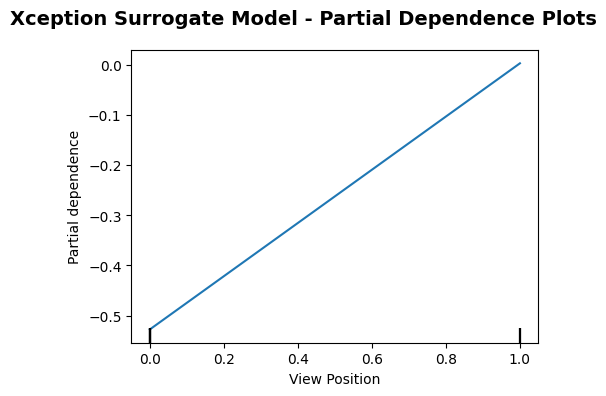

PDP saved to: /kaggle/working/outputs/xception_metadata_pdp.png


In [75]:
# ============================================================
# FIXED XCEPTION PDP IMPLEMENTATION — MEMORY SAFE
# Uses GlobalAveragePooling embeddings instead of 10x10x2048 maps
# ============================================================

import os
import gc
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications.xception import preprocess_input

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# ============================================================
# 1. SETTINGS
# ============================================================

SAVE_DIR = "/kaggle/working/outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

PATH_COL = "path"
LABEL_COL = "label"

METADATA_COLS = [
    "Patient Age",
    "Patient Gender",
    "View Position"
]

BATCH_SIZE = 8   # small batch to avoid GPU OOM


# ============================================================
# 2. PREPARE METADATA
# ============================================================

def prepare_metadata(df):
    df = df.copy()

    available_cols = [c for c in METADATA_COLS if c in df.columns]
    print("Available metadata columns:", available_cols)

    meta_df = df[available_cols].copy()

    if "Patient Age" in meta_df.columns:
        meta_df["Patient Age"] = pd.to_numeric(
            meta_df["Patient Age"],
            errors="coerce"
        )
        meta_df["Patient Age"] = meta_df["Patient Age"].fillna(
            meta_df["Patient Age"].median()
        )

    if "Patient Gender" in meta_df.columns:
        meta_df["Patient Gender"] = meta_df["Patient Gender"].astype(str).map({
            "M": 1,
            "Male": 1,
            "male": 1,
            "F": 0,
            "Female": 0,
            "female": 0
        })
        meta_df["Patient Gender"] = meta_df["Patient Gender"].fillna(0)

    if "View Position" in meta_df.columns:
        meta_df["View Position"] = meta_df["View Position"].astype(str).map({
            "PA": 0,
            "AP": 1,
            "L": 2,
            "LL": 2
        })
        meta_df["View Position"] = meta_df["View Position"].fillna(0)

    return meta_df.astype(np.float32)


# ============================================================
# 3. LOAD IMAGE FOR XCEPTION
# ============================================================

def load_xception_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.image.grayscale_to_rgb(img)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img


def build_image_dataset(paths, batch_size=8):
    ds = tf.data.Dataset.from_tensor_slices(paths)

    ds = ds.map(
        load_xception_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


# ============================================================
# 4. FIND XCEPTION BACKBONE
# ============================================================

def get_xception_backbone(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            print("Backbone found:", layer.name)
            return layer

    raise ValueError("No Xception backbone found inside xception_model.")


# ============================================================
# 5. MEMORY-SAFE EMBEDDING EXTRACTION
# ============================================================

def extract_xception_embeddings_safe(model, df, batch_size=8):
    """
    Extract compact vector embeddings.

    Important:
    If backbone output is 4D: (batch, h, w, channels)
    we apply GlobalAveragePooling2D to convert it to:
    (batch, channels)

    This prevents OOM.
    """

    backbone = get_xception_backbone(model)

    backbone_output = backbone.output

    if len(backbone_output.shape) == 4:
        print("Backbone output is 4D feature map:", backbone_output.shape)
        print("Applying GlobalAveragePooling2D to make vector embeddings.")

        pooled_output = GlobalAveragePooling2D(name="pdp_gap")(backbone_output)

        embedding_model = Model(
            inputs=backbone.input,
            outputs=pooled_output
        )

    else:
        print("Backbone output is already vector:", backbone_output.shape)

        embedding_model = Model(
            inputs=backbone.input,
            outputs=backbone.output
        )

    paths = df[PATH_COL].values
    ds = build_image_dataset(paths, batch_size=batch_size)

    embeddings = embedding_model.predict(
        ds,
        verbose=1
    )

    embeddings = embeddings.astype(np.float32)

    print("Final embeddings shape:", embeddings.shape)

    tf.keras.backend.clear_session()
    gc.collect()

    return embeddings


# ============================================================
# 6. BUILD SURROGATE DATASET
# ============================================================

def build_surrogate_dataset_safe(model, df):
    print("Extracting compact Xception embeddings...")

    embeddings = extract_xception_embeddings_safe(
        model=model,
        df=df,
        batch_size=BATCH_SIZE
    )

    print("Preparing metadata...")

    metadata = prepare_metadata(df)

    embedding_feature_names = [
        f"embedding_{i}" for i in range(embeddings.shape[1])
    ]

    embedding_df = pd.DataFrame(
        embeddings,
        columns=embedding_feature_names
    )

    metadata = metadata.reset_index(drop=True)
    embedding_df = embedding_df.reset_index(drop=True)

    X_combined = pd.concat(
        [embedding_df, metadata],
        axis=1
    )

    y = df[LABEL_COL].values.astype(int)

    print("Combined X shape:", X_combined.shape)
    print("y shape:", y.shape)

    return X_combined, y, metadata.columns.tolist()


# ============================================================
# 7. TRAIN SURROGATE MODEL
# ============================================================

def train_surrogate_model(X, y):
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    surrogate = GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    surrogate.fit(X_train, y_train)

    preds = surrogate.predict(X_val)
    probs = surrogate.predict_proba(X_val)[:, 1]

    print("\nSurrogate Model Evaluation")
    print("=" * 40)
    print("Accuracy:", round(accuracy_score(y_val, preds), 4))
    print("ROC-AUC:", round(roc_auc_score(y_val, probs), 4))
    print("\nClassification Report:")
    print(classification_report(y_val, preds))

    return surrogate, X_train, X_val, y_train, y_val


# ============================================================
# 8. SAFE PDP PLOT
# ============================================================

def plot_safe_metadata_pdp(
    surrogate,
    X_train,
    metadata_feature_names,
    save_path="/kaggle/working/outputs/xception_metadata_pdp.png"
):
    valid_features = []

    print("\nChecking metadata features for PDP")
    print("=" * 40)

    for feature in metadata_feature_names:

        if feature not in X_train.columns:
            print(f"Skipping {feature}: not found")
            continue

        unique_values = X_train[feature].dropna().unique()

        print(f"\nFeature: {feature}")
        print("Unique values:", unique_values[:10])
        print("Number of unique values:", len(unique_values))

        if len(unique_values) > 1:
            valid_features.append(feature)
        else:
            print(f"Skipping {feature}: constant feature")

    print("\nValid PDP features:", valid_features)

    if len(valid_features) == 0:
        print("No valid metadata features available for PDP.")
        return None

    fig, ax = plt.subplots(
        1,
        len(valid_features),
        figsize=(5 * len(valid_features), 4)
    )

    if len(valid_features) == 1:
        ax = [ax]

    PartialDependenceDisplay.from_estimator(
        estimator=surrogate,
        X=X_train,
        features=valid_features,
        feature_names=X_train.columns.tolist(),
        grid_resolution=20,
        percentiles=(0.0, 1.0),
        ax=ax
    )

    plt.suptitle(
        "Xception Surrogate Model - Partial Dependence Plots",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("PDP saved to:", save_path)

    return valid_features


# ============================================================
# 9. RUN FULL PIPELINE
# ============================================================

X_combined, y, metadata_feature_names = build_surrogate_dataset_safe(
    model=xception_model,
    df=test_df
)

surrogate, X_train_combined, X_val_combined, y_train, y_val = train_surrogate_model(
    X_combined,
    y
)

valid_pdp_features = plot_safe_metadata_pdp(
    surrogate=surrogate,
    X_train=X_train_combined,
    metadata_feature_names=metadata_feature_names,
    save_path="/kaggle/working/outputs/xception_metadata_pdp.png"
)